In [16]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [17]:
train_df = pd.read_csv("train_no_outliers.csv")
val_df = pd.read_csv("validation_no_outliers.csv")
test_df = pd.read_csv("test_no_outliers.csv")

print(f"Train: {train_df.shape}")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")


Train: (128764, 38)
Val:   (31553, 38)
Test:  (11955, 38)


In [20]:
exclude_cols = ["log_price", "ClosePrice", "CloseDate", "price_ratio"]
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["log_price"]
y_val = val_df["log_price"]
y_test = test_df["log_price"]

print(f"Feature count: {len(feature_cols)}")


Feature count: 35


## DecisionTree

In [21]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_train_dt = dt_model.predict(X_train)
y_pred_val_dt = dt_model.predict(X_val)
y_pred_test_dt = dt_model.predict(X_test)

r2_train_dt = r2_score(y_train, y_pred_train_dt)
r2_val_dt = r2_score(y_val, y_pred_val_dt)
r2_test_dt = r2_score(y_test, y_pred_test_dt)

print(
    f"Decision Tree — Train R²: {r2_train_dt:.4f}, Val R²: {r2_val_dt:.4f}, Test R²: {r2_test_dt:.4f}"
)


Decision Tree — Train R²: 0.9999, Val R²: 0.8646, Test R²: 0.8604


## Cross Validation

In [26]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Combine train set for cross-validation (must be sorted by time)
train_df_sorted = (
    train_df.sort_values("CloseDate") if "CloseDate" in train_df.columns else train_df
)

param_grid = {"max_depth": [3, 5, 7, 10, 15, 20, None]}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print(f"Best max_depth: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_max_depth", "mean_test_score", "std_test_score"]
]
print(cv_results.sort_values("mean_test_score", ascending=False))


Best max_depth: {'max_depth': 10}
Best CV R²: 0.8818
  param_max_depth  mean_test_score  std_test_score
3              10         0.881767        0.007128
4              15         0.871957        0.009905
2               7         0.869859        0.001635
5              20         0.857774        0.010268
6            None         0.851278        0.007044
1               5         0.841165        0.002020
0               3         0.751593        0.005097


In [27]:
best_max_depth = grid_search.best_params_["max_depth"]

dt_model_best = DecisionTreeRegressor(max_depth=best_max_depth, random_state=42)
dt_model_best.fit(X_train, y_train)

y_pred_train_best = dt_model_best.predict(X_train)
y_pred_val_best = dt_model_best.predict(X_val)
y_pred_test_best = dt_model_best.predict(X_test)

r2_train_best = r2_score(y_train, y_pred_train_best)
r2_val_best = r2_score(y_val, y_pred_val_best)
r2_test_best = r2_score(y_test, y_pred_test_best)

print(f"Decision Tree (max_depth={best_max_depth})")
print(
    f"Train R²: {r2_train_best:.4f}, Val R²: {r2_val_best:.4f}, Test R²: {r2_test_best:.4f}"
)


Decision Tree (max_depth=10)
Train R²: 0.9137, Val R²: 0.8914, Test R²: 0.8920


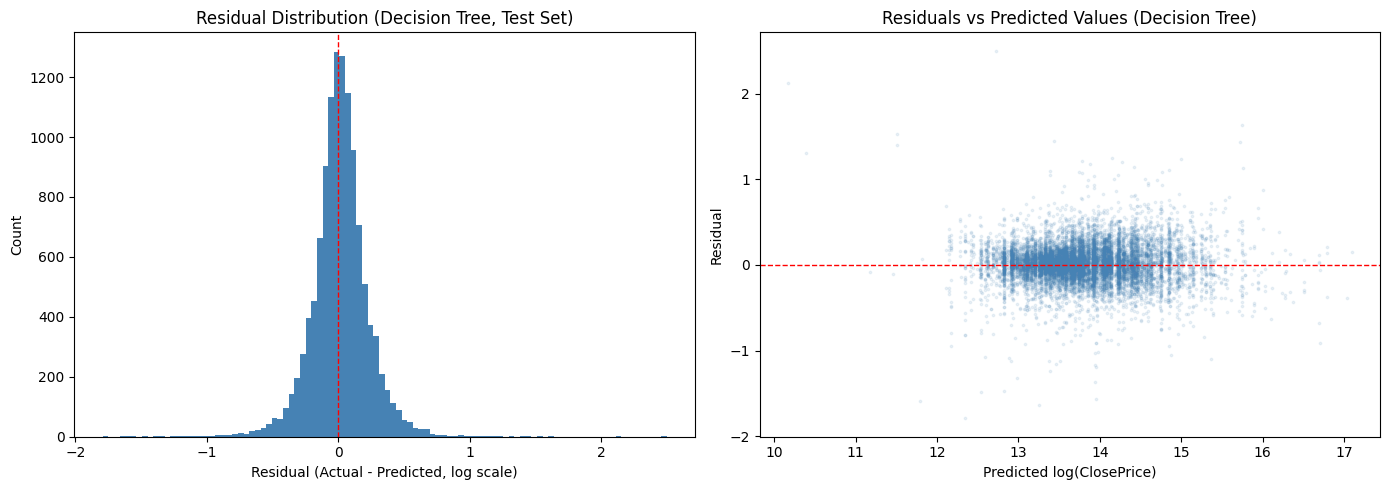

In [40]:
import matplotlib.pyplot as plt

# Predictions from Decision Tree (max_depth=10) model
y_pred_test_dt_final = dt_model_best.predict(X_test)
residuals_test_dt = y_test - y_pred_test_dt_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of residuals
axes[0].hist(residuals_test_dt, bins=100, color="steelblue")
axes[0].set_title("Residual Distribution (Decision Tree, Test Set)")
axes[0].set_xlabel("Residual (Actual - Predicted, log scale)")
axes[0].set_ylabel("Count")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

# Residuals vs Predicted
axes[1].scatter(
    y_pred_test_dt_final, residuals_test_dt, alpha=0.1, s=3, color="steelblue"
)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Residuals vs Predicted Values (Decision Tree)")
axes[1].set_xlabel("Predicted log(ClosePrice)")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


In [44]:
def cumulative_gains(y_true, y_pred, n_bins=10):
    tmp = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    tmp = tmp.sort_values("y_pred", ascending=False).reset_index(drop=True)

    tmp["cum_actual"] = tmp["y_true"].cumsum()
    total_actual = tmp["y_true"].sum()
    tmp["cum_pct_actual"] = tmp["cum_actual"] / total_actual * 100
    tmp["cum_pct_population"] = (np.arange(1, len(tmp) + 1) / len(tmp)) * 100

    bin_edges = np.linspace(0, len(tmp), n_bins + 1).astype(int)
    pct_population = [0]
    pct_actual = [0]
    for edge in bin_edges[1:]:
        pct_population.append(tmp["cum_pct_population"].iloc[edge - 1])
        pct_actual.append(tmp["cum_pct_actual"].iloc[edge - 1])

    return pct_population, pct_actual


train_actual_price = np.exp(y_train)
test_actual_price = np.exp(y_test)


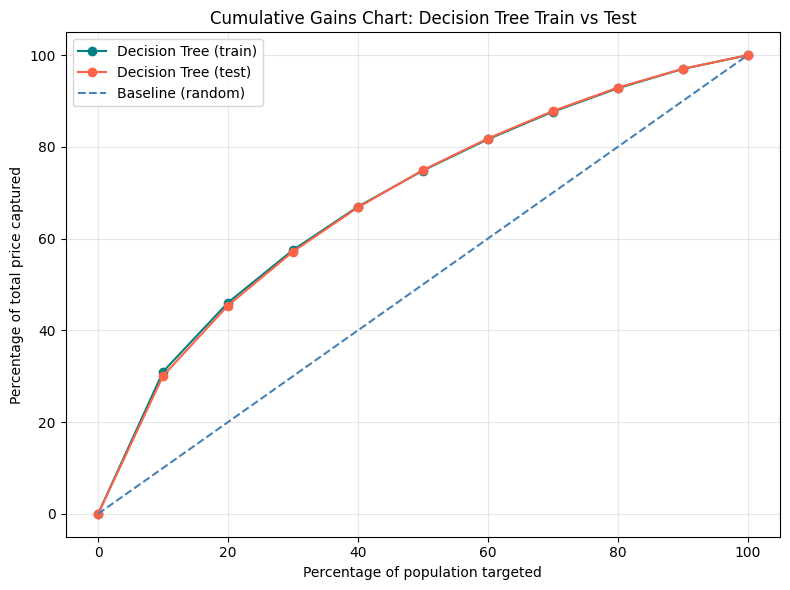

In [46]:
pred_price_dt_train = np.exp(dt_model_best.predict(X_train))
pred_price_dt_test = np.exp(dt_model_best.predict(X_test))

pop_dt_train, gain_dt_train = cumulative_gains(train_actual_price, pred_price_dt_train)
pop_dt_test, gain_dt_test = cumulative_gains(test_actual_price, pred_price_dt_test)

plt.figure(figsize=(8, 6))
plt.plot(
    pop_dt_train, gain_dt_train, marker="o", label="Decision Tree (train)", color="teal"
)
plt.plot(
    pop_dt_test, gain_dt_test, marker="o", label="Decision Tree (test)", color="tomato"
)
plt.plot(
    [0, 100], [0, 100], linestyle="--", color="steelblue", label="Baseline (random)"
)

plt.xlabel("Percentage of population targeted")
plt.ylabel("Percentage of total price captured")
plt.title("Cumulative Gains Chart: Decision Tree Train vs Test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Random Forest

In [28]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_train_rf = rf_model.predict(X_train)
y_pred_val_rf = rf_model.predict(X_val)
y_pred_test_rf = rf_model.predict(X_test)

r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_val_rf = r2_score(y_val, y_pred_val_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print(f"Random Forest (default, n_estimators=100)")
print(f"Train R²: {r2_train_rf:.4f}")
print(f"Val R²:   {r2_val_rf:.4f}")
print(f"Test R²:  {r2_test_rf:.4f}")


Random Forest (default, n_estimators=100)
Train R²: 0.9906
Val R²:   0.9291
Test R²:  0.9304


In [29]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "max_features": ["sqrt", "log2", 0.5],
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)

grid_search_rf.fit(X_train, y_train)

print(f"Best params: {grid_search_rf.best_params_}")
print(f"Best CV R²: {grid_search_rf.best_score_:.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits


/opt/base-uv/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'max_depth': None, 'max_features': 0.5, 'n_estimators': 300}
Best CV R²: 0.9278


In [30]:
best_params_rf = grid_search_rf.best_params_

rf_model_tuned = RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)
rf_model_tuned.fit(X_train, y_train)

y_pred_train_rf_tuned = rf_model_tuned.predict(X_train)
y_pred_val_rf_tuned = rf_model_tuned.predict(X_val)
y_pred_test_rf_tuned = rf_model_tuned.predict(X_test)

r2_train_rf_tuned = r2_score(y_train, y_pred_train_rf_tuned)
r2_val_rf_tuned = r2_score(y_val, y_pred_val_rf_tuned)
r2_test_rf_tuned = r2_score(y_test, y_pred_test_rf_tuned)

print(f"Random Forest (tuned: {best_params_rf})")
print(f"Train R²: {r2_train_rf_tuned:.4f}")
print(f"Val R²:   {r2_val_rf_tuned:.4f}")
print(f"Test R²:  {r2_test_rf_tuned:.4f}")


Random Forest (tuned: {'max_depth': None, 'max_features': 0.5, 'n_estimators': 300})
Train R²: 0.9912
Val R²:   0.9320
Test R²:  0.9331


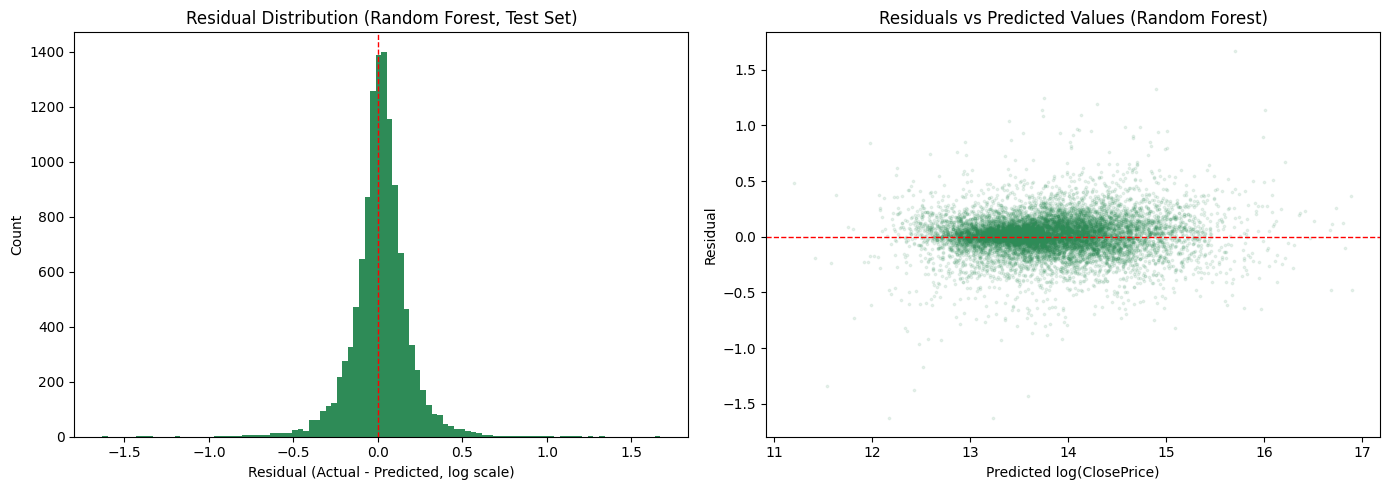

In [38]:
import matplotlib.pyplot as plt

# Predictions from Random Forest tuned model
y_pred_test_rf_final = rf_model_tuned.predict(X_test)
residuals_test_rf = y_test - y_pred_test_rf_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of residuals
axes[0].hist(residuals_test_rf, bins=100, color="seagreen")
axes[0].set_title("Residual Distribution (Random Forest, Test Set)")
axes[0].set_xlabel("Residual (Actual - Predicted, log scale)")
axes[0].set_ylabel("Count")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

# Residuals vs Predicted
axes[1].scatter(
    y_pred_test_rf_final, residuals_test_rf, alpha=0.1, s=3, color="seagreen"
)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Residuals vs Predicted Values (Random Forest)")
axes[1].set_xlabel("Predicted log(ClosePrice)")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


In [ ]:
rf_comparison = pd.DataFrame(
    [
        {
            "version": "Default (n_estimators=100)",
            "Train_R2": r2_train_rf,
            "Val_R2": r2_val_rf,
            "Test_R2": r2_test_rf,
            "Train_Val_Gap": r2_train_rf - r2_val_rf,
        },
        {
            "version": f"Tuned {best_params_rf}",
            "Train_R2": r2_train_rf_tuned,
            "Val_R2": r2_val_rf_tuned,
            "Test_R2": r2_test_rf_tuned,
            "Train_Val_Gap": r2_train_rf_tuned - r2_val_rf_tuned,
        },
    ]
)
print(rf_comparison)


                                             version  Train_R2  Val_R2  \
0                         Default (n_estimators=100)    0.9137  0.8914   
1  Tuned {'max_depth': None, 'max_features': 0.5,...    0.9912  0.9320   

   Test_R2  Train_Val_Gap  
0   0.8920         0.0223  
1   0.9331         0.0592  


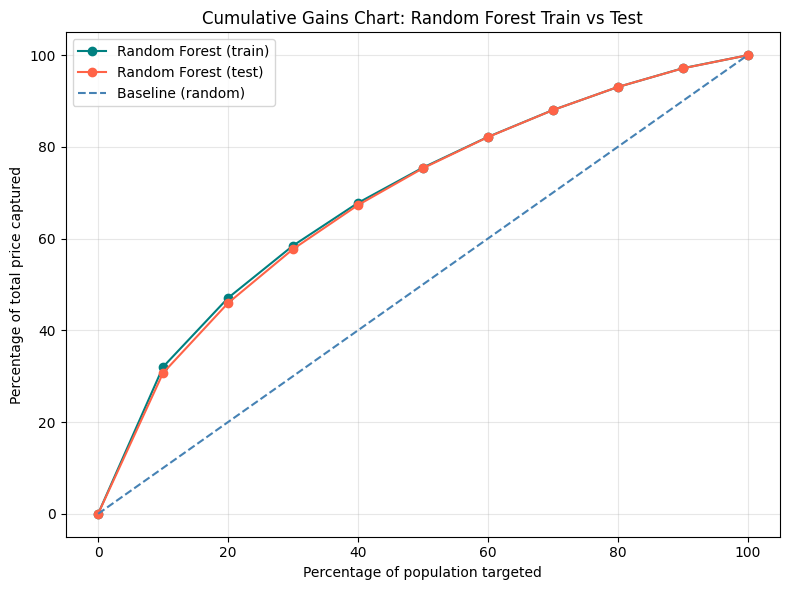

In [47]:
pred_price_rf_train = np.exp(rf_model_tuned.predict(X_train))
pred_price_rf_test = np.exp(rf_model_tuned.predict(X_test))

pop_rf_train, gain_rf_train = cumulative_gains(train_actual_price, pred_price_rf_train)
pop_rf_test, gain_rf_test = cumulative_gains(test_actual_price, pred_price_rf_test)

plt.figure(figsize=(8, 6))
plt.plot(
    pop_rf_train, gain_rf_train, marker="o", label="Random Forest (train)", color="teal"
)
plt.plot(
    pop_rf_test, gain_rf_test, marker="o", label="Random Forest (test)", color="tomato"
)
plt.plot(
    [0, 100], [0, 100], linestyle="--", color="steelblue", label="Baseline (random)"
)

plt.xlabel("Percentage of population targeted")
plt.ylabel("Percentage of total price captured")
plt.title("Cumulative Gains Chart: Random Forest Train vs Test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [36]:
tuned_comparison = pd.DataFrame(
    [
        {
            "model": "Decision Tree (max_depth=10)",
            "Train_R2": r2_train_best,
            "Val_R2": r2_val_best,
            "Test_R2": r2_test_best,
        },
        {
            "model": "Random Forest (tuned)",
            "Train_R2": r2_train_rf_tuned,
            "Val_R2": r2_val_rf_tuned,
            "Test_R2": r2_test_rf_tuned,
        },
    ]
)
tuned_comparison["Train_Val_Gap"] = (
    tuned_comparison["Train_R2"] - tuned_comparison["Val_R2"]
)

pd.set_option("display.float_format", "{:.4f}".format)
print(tuned_comparison)


                          model  Train_R2  Val_R2  Test_R2  Train_Val_Gap
0  Decision Tree (max_depth=10)    0.9137  0.8914   0.8920         0.0223
1         Random Forest (tuned)    0.9912  0.9320   0.9331         0.0592
